# 05 — Standardised Approach Risk Weights and Mortgage LTV

## How the prescribed risk weight is selected

EAD is available for every loan. This notebook selects the applicable prescribed risk weight from the relevant Basel grid.

The risk weight converts EAD into RWA. Higher risk weights create more RWA and require more capital for the same exposure amount.

### How to read the risk-weight tables

| Term | Simple meaning |
|---|---|
| Risk weight | the prescribed percentage applied to EAD |
| LTV | loan amount divided by prudent property value |
| Prudent property value | the lower of the synthetic origination and current values in this implementation |
| Income-dependent property | a mortgage whose repayment materially depends on cash flow generated by the property |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display as notebook_display
from pandas.io.formats.style import Styler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from basel_credit_risk.config import load_all_config

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)


def display(*objects, **kwargs):
    # Show complete table text and wrap long descriptions in saved notebook output.
    wrapped_objects = []
    for displayed_object in objects:
        if isinstance(displayed_object, pd.DataFrame):
            displayed_object = displayed_object.style
        if isinstance(displayed_object, Styler):
            displayed_object = displayed_object.set_properties(**{
                "white-space": "normal",
                "overflow-wrap": "anywhere",
                "text-align": "left",
                "vertical-align": "top",
                "max-width": "420px",
            }).set_table_styles([
                {"selector": "table", "props": [("width", "100%"), ("table-layout", "auto")]},
                {"selector": "th", "props": [
                    ("white-space", "normal"),
                    ("overflow-wrap", "anywhere"),
                    ("word-break", "break-word"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("max-width", "180px"),
                ]},
            ], overwrite=False)
        wrapped_objects.append(displayed_object)
    return notebook_display(*wrapped_objects, **kwargs)

configs = load_all_config(ROOT / "config")
raw = pd.read_csv(ROOT / "data/generated/current_portfolio.csv.gz", low_memory=False)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)

print(f"Portfolio represented below: {len(loans):,} synthetic loan-level exposures")

Portfolio represented below: 30,000 synthetic loan-level exposures


## Rating-based and fixed risk-weight grids

Sovereign, bank and corporate exposures use rating tables in this selected global Basel scope. Retail and SME classes use fixed weights. National implementation and external-rating eligibility can change these treatments.

In [2]:
for exposure_class, weights in configs["sa_risk_weights"]["rating_risk_weights"].items():
    print(exposure_class.upper())
    display(pd.Series(weights, name="Risk weight").to_frame())

print("FIXED WEIGHTS")
display(pd.Series(configs["sa_risk_weights"]["fixed_risk_weights"], name="Risk weight").to_frame())

SOVEREIGN


,Risk weight
AAA,0.000000
AA,0.000000
A,0.200000
BBB,0.500000
BB,1.000000
B,1.000000
CCC,1.500000
UNRATED,1.000000


BANK


,Risk weight
AAA,0.200000
AA,0.200000
A,0.300000
BBB,0.500000
BB,1.000000
B,1.500000
CCC,1.500000
UNRATED,0.500000


CORPORATE


,Risk weight
AAA,0.200000
AA,0.200000
A,0.500000
BBB,0.750000
BB,1.000000
B,1.500000
CCC,1.500000
UNRATED,1.000000


FIXED WEIGHTS


,Risk weight
corporate_sme,0.850000
regulatory_retail,0.750000
retail_transactor,0.450000
revolving_retail,0.750000
other_retail,1.000000
other,1.000000
defaulted,1.500000


The tables are rule references, not portfolio results. Each loan retrieves one value after its class, rating and other eligibility fields are known.

## Residential mortgage LTV grids

Mortgage EAD is not caused by LTV. LTV selects the risk weight. The loan amount used in LTV includes outstanding principal plus committed undrawn mortgage exposure. The engine then divides by prudent property value.

In [3]:
owner_grid = pd.DataFrame(configs["sa_risk_weights"]["mortgage_ltv_bands_not_income_dependent"])
income_grid = pd.DataFrame(configs["sa_risk_weights"]["mortgage_ltv_bands_income_dependent"])
for grid in (owner_grid, income_grid):
    grid["LTV band"] = grid["display_band"].fillna(
        "Up to " + grid["max_ltv"].map(lambda value: f"{value:.0%}")
    )
owner_grid["Mortgage repayment"] = "Not materially dependent on property cash flow"
income_grid["Mortgage repayment"] = "Materially dependent on property cash flow"
ltv_table = pd.concat([owner_grid, income_grid], ignore_index=True)
display(ltv_table[["Mortgage repayment", "LTV band", "risk_weight"]].rename(columns={"risk_weight": "Risk weight"}))

,Mortgage repayment,LTV band,Risk weight
0,Not materially dependent on property cash flow,Up to 50%,0.200000
1,Not materially dependent on property cash flow,Up to 60%,0.250000
2,Not materially dependent on property cash flow,Up to 80%,0.300000
3,Not materially dependent on property cash flow,Up to 90%,0.400000
4,Not materially dependent on property cash flow,Up to 100%,0.500000
5,Not materially dependent on property cash flow,Above 100%,0.700000
6,Materially dependent on property cash flow,Up to 50%,0.300000
7,Materially dependent on property cash flow,Up to 60%,0.350000
8,Materially dependent on property cash flow,Up to 80%,0.450000
9,Materially dependent on property cash flow,Up to 90%,0.600000


The last row means LTV above 100%. The number `999` exists only inside the lookup configuration to represent an open-ended final band; it is not an LTV and is not used as a customer value.

## What the mortgage grid looks like

The step chart turns the table into the actual decision applied to a mortgage. Moving right means the loan is larger relative to the prudent property value. Each jump increases the prescribed risk weight, with the income-dependent route remaining higher.

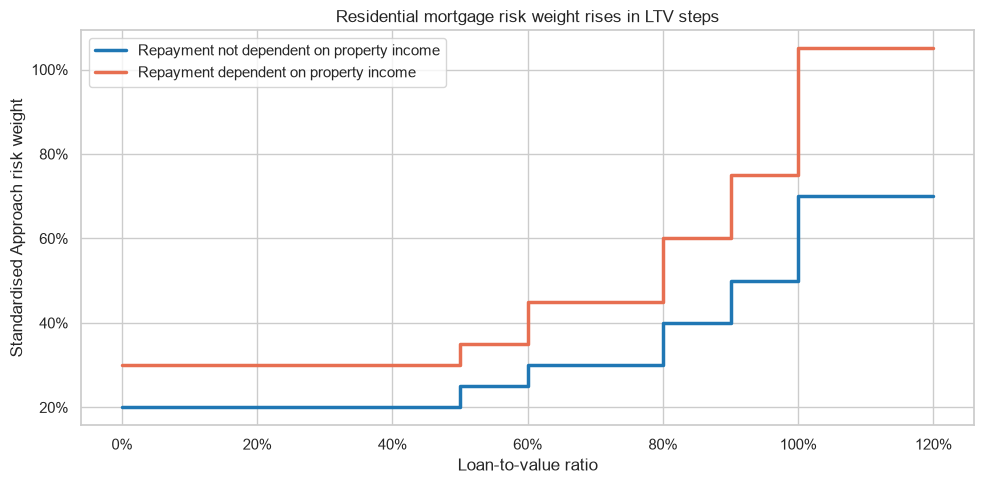

In [4]:
ltv_axis = [0.0, 0.50, 0.60, 0.80, 0.90, 1.00, 1.20]
owner_weights = [0.20, 0.25, 0.30, 0.40, 0.50, 0.70, 0.70]
income_weights = [0.30, 0.35, 0.45, 0.60, 0.75, 1.05, 1.05]

plt.figure(figsize=(10, 5))
plt.step(ltv_axis, owner_weights, where="post", linewidth=2.5, label="Repayment not dependent on property income", color=COLORS[1])
plt.step(ltv_axis, income_weights, where="post", linewidth=2.5, label="Repayment dependent on property income", color=COLORS[5])
plt.xlabel("Loan-to-value ratio")
plt.ylabel("Standardised Approach risk weight")
plt.title("Residential mortgage risk weight rises in LTV steps")
plt.gca().xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.legend()
plt.tight_layout()
plt.show()

A mortgage just above a band boundary receives the next weight on the whole exposure under this implementation. This is why property value changes can affect Standardised Approach RWA even when the outstanding loan balance does not change.

At the same LTV, an income-dependent mortgage generally receives a higher weight because repayment relies more heavily on the property's cash generation. This is separate from the property value's effect on recovery and downturn LGD in IRB.

## Loan-level mortgage examples

The table selects one mortgage from each applied risk-weight band and shows the complete LTV-to-risk-weight path.

In [5]:
mortgages = loans.loc[loans["performing_exposure_class"].eq("residential_real_estate")].copy()
mortgage_examples = (
    mortgages.sort_values(["sa_risk_weight", "ltv"])
    .groupby(["property_cashflow_dependent", "sa_risk_weight"], as_index=False)
    .first()[["exposure_id", "property_cashflow_dependent", "ltv_loan_amount", "property_value_prudent", "ltv", "sa_risk_weight", "sa_rule_id"]]
)
mortgage_examples[["ltv_loan_amount", "property_value_prudent"]] /= CRORE
display(mortgage_examples.rename(columns={"ltv_loan_amount": "Loan amount (INR crore)", "property_value_prudent": "Prudent property value (INR crore)"}))

,exposure_id,property_cashflow_dependent,Loan amount (INR crore),Prudent property value (INR crore),ltv,sa_risk_weight,sa_rule_id
0,EXP-0000827,False,0.343392,1.716958,0.200000,0.200000,SA_MORTGAGE_OWNER_REPAYMENT_LTV_0.20
1,EXP-0004698,False,0.373799,0.747597,0.500001,0.250000,SA_MORTGAGE_OWNER_REPAYMENT_LTV_0.25
2,EXP-0008081,False,0.460081,0.766795,0.600005,0.300000,SA_MORTGAGE_OWNER_REPAYMENT_LTV_0.30
3,EXP-0006177,False,0.236996,0.296199,0.800126,0.400000,SA_MORTGAGE_OWNER_REPAYMENT_LTV_0.40
4,EXP-0004250,False,0.393687,0.437305,0.900256,0.500000,SA_MORTGAGE_OWNER_REPAYMENT_LTV_0.50
5,EXP-0004330,False,0.283078,0.283003,1.000263,0.700000,SA_MORTGAGE_OWNER_REPAYMENT_LTV_0.70
6,EXP-0009049,False,0.366031,1.830153,0.200000,1.500000,SA_DEFAULTED
7,EXP-0002841,True,0.483427,2.417133,0.200000,0.300000,SA_MORTGAGE_INCOME_DEPENDENT_LTV_0.30
8,EXP-0009014,True,0.457032,0.910250,0.502095,0.350000,SA_MORTGAGE_INCOME_DEPENDENT_LTV_0.35
9,EXP-0002648,True,0.653164,1.088331,0.600152,0.450000,SA_MORTGAGE_INCOME_DEPENDENT_LTV_0.45


The rule ID identifies both the cash-flow dependency treatment and the selected LTV weight. The same fields remain on all mortgage rows, allowing the portfolio total to be traced back to individual properties and loans.

Each loan now has an applicable Standardised Approach risk weight and a rule ID explaining its source. Mortgage weights are explicitly linked to LTV bands.